In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
pd.pandas.set_option('display.max_columns',None)
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split,RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import joblib

In [2]:
train = pd.read_csv('train.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(train.shape)

(1460, 81)


In [4]:
train_id = train['Id']

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# EDA

##### SalePrice distribution before Log Transform (Right Skewed) and it's skewness

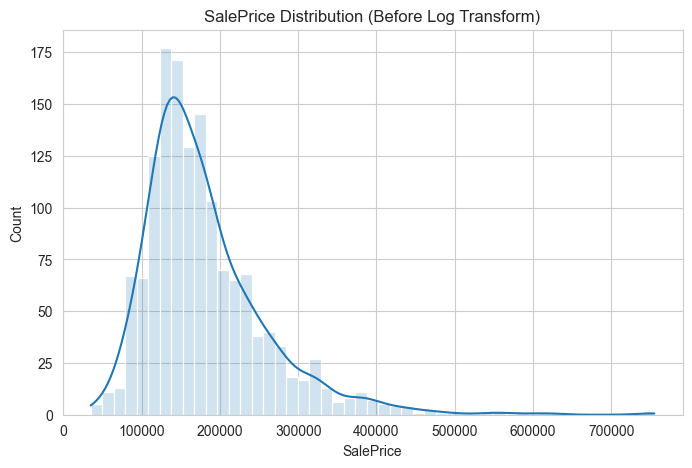

Skewness: 1.8828757597682129


In [7]:
plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'],alpha=0.2,kde=True)
plt.title("SalePrice Distribution (Before Log Transform)")
plt.show()

print(f"Skewness: {train['SalePrice'].skew()}")

##### SalePrice distribution after Log Transform and it's skewness

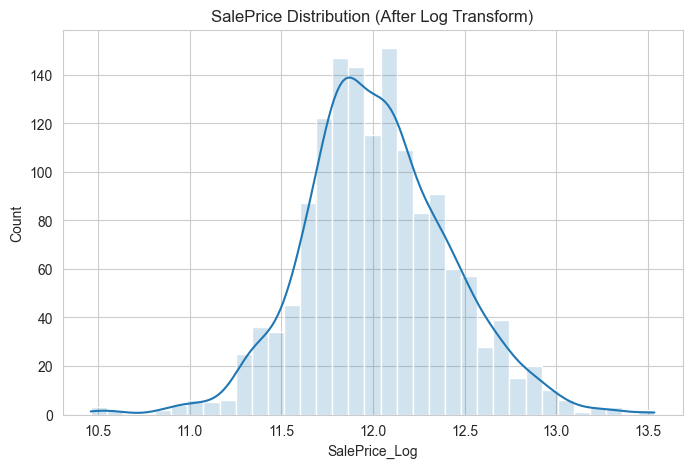

Skewness: 0.12134661989685333


In [8]:
train['SalePrice_Log']= np.log1p(train['SalePrice'])

plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice_Log'],alpha=0.2,kde=True)
plt.title("SalePrice Distribution (After Log Transform)")
plt.show()

print(f"Skewness: {train['SalePrice_Log'].skew()}")

##### Correlation with target column

In [9]:
numeric_cols= train.select_dtypes(include=[np.number])
corr= numeric_cols.corr()['SalePrice'].sort_values(ascending=False)
print(f"Top correlated features: \n{corr.head(15)}")

Top correlated features: 
SalePrice        1.000000
SalePrice_Log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
Name: SalePrice, dtype: float64


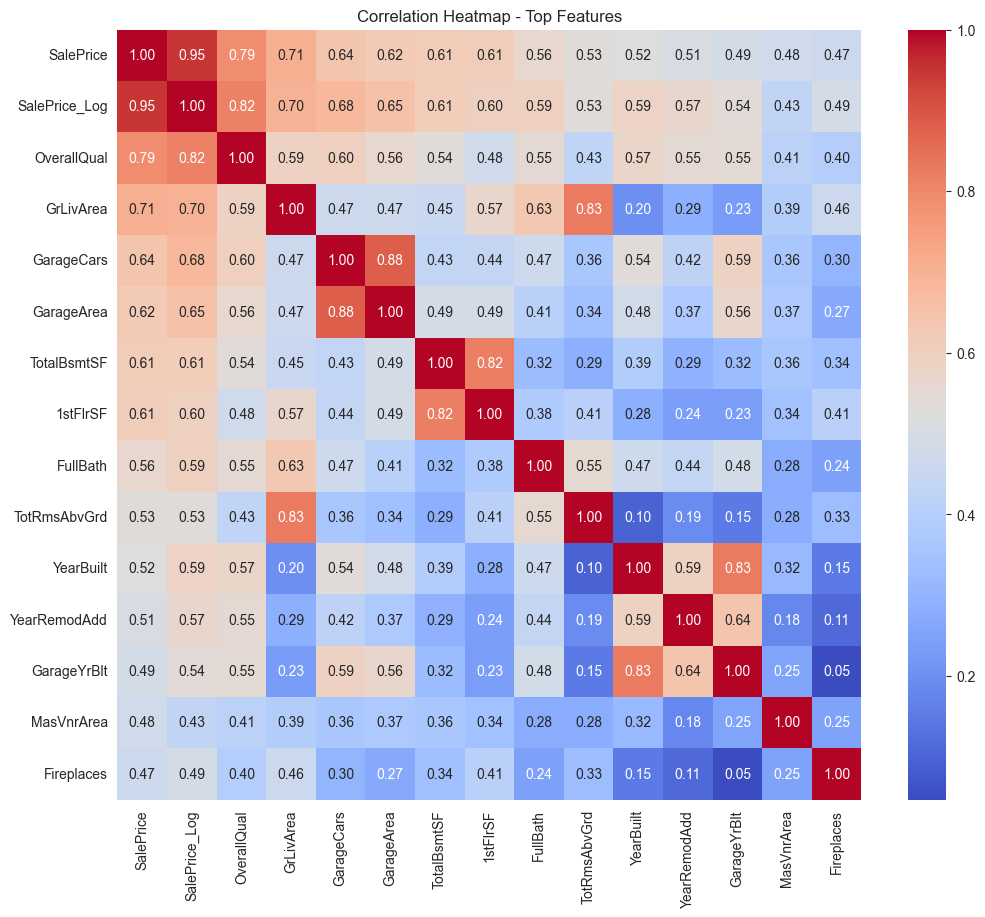

In [10]:
plt.figure(figsize=(12, 10))
top_corr_features = corr.head(15).index
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap - Top Features")
plt.show()

##### Handle Missing Values

In [11]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    train[col] = train[col].fillna('None')

# GarageYrBlt: filling with 0 creates a fake "year 0" outlier that badly distorts
# scaling/log-transform later. Better fix -> fill with YearBuilt (garage is usually
# built same time as house)
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])

zero_cols = ['GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    train[col] = train[col].fillna(0)

In [12]:
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [13]:
mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st',
             'Exterior2nd', 'SaleType', 'Functional']
for col in mode_cols:
    if col in train.columns:
        train[col] = train[col].fillna(train[col].mode()[0])

if 'Utilities' in train.columns:
    train.drop(['Utilities'], axis=1, inplace=True)

print("\nRemaining missing values:", train.isnull().sum().sum())


Remaining missing values: 0


##### Feature Engineering

In [14]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
train['TotalBath'] = (train['FullBath'] + 0.5 * train['HalfBath'] +
                       train['BsmtFullBath'] + 0.5 * train['BsmtHalfBath'])
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
train['TotalPorchSF'] = (train['OpenPorchSF'] + train['EnclosedPorch'] +
                          train['3SsnPorch'] + train['ScreenPorch'])
train['HasPool'] = (train['PoolArea'] > 0).astype(int)
train['HasGarage'] = (train['GarageArea'] > 0).astype(int)
train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)

# MSSubClass is numeric but is actually categorical
train['MSSubClass'] = train['MSSubClass'].astype(str)

In [15]:
target_cols = ['SalePrice', 'SalePrice_Log']
numeric_feats = train.select_dtypes(include=[np.number]).columns
numeric_feats = [c for c in numeric_feats if c not in target_cols + ['Id']]

skewed_feats = train[numeric_feats].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75].index

for feat in high_skew:
    train[feat] = np.log1p(train[feat])

# Splitting and Scaling

In [16]:
y = train['SalePrice_Log'].values
X = train.drop(['Id', 'SalePrice', 'SalePrice_Log'], axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)
scale= StandardScaler()
X_train= scale.fit_transform(X_train)
X_test= scale.transform(X_test)

# Model Evaluation

In [17]:
kfold= KFold(n_splits=5, shuffle=True,random_state=42)
result={}
trained_models={}

def evaluate(name,model,X_tr,X_te,y_tr,y_te):
    model.fit(X_tr,y_tr)
    test_pred= model.predict(X_te)
    train_pred= model.predict(X_tr)
    rmse_test= np.sqrt(mean_squared_error(y_te,test_pred))
    rmse_train= np.sqrt(mean_squared_error(y_tr,train_pred))
    r2_test= r2_score(y_te,test_pred)
    r2_train= r2_score(y_tr,train_pred)
    mae_test= mean_absolute_error(y_te,test_pred)
    mae_train= mean_absolute_error(y_tr,train_pred)
    cv_rmse = np.sqrt(-cross_val_score(model, X_tr, y_tr, cv=kfold, scoring='neg_mean_squared_error')).mean()
    
    result[name]={'RMSE of Train':rmse_train,'RMSE of Test':rmse_test,'MAE of Train':mae_train,'MAE of Test':mae_test,'R2 Score of Train':r2_train,'R2 Score of Test':r2_test,'CV RMSE':cv_rmse}

    trained_models[name]=model

    print(f"\n{name}")
    print(f"  Validation RMSE train & test: {rmse_train:.4f},{rmse_test:.4f} | MAE train & test: {mae_train:.4f},{mae_test:.4f} | R2 train & test: {r2_train:.4f},{r2_test:.4f}")
    print(f"  Cross-Val RMSE : {cv_rmse:.4f}")


# Model 1: Linear Regression
evaluate('Linear Regression',LinearRegression(),X_train,X_test,y_train,y_test)

# Model 2: Lasso
lasso_paras= {'alpha':[0.0001,0.0005,0.001,0.005,0.01,0.05,0.1]}
lasso_search= RandomizedSearchCV(Lasso(max_iter=1000),lasso_paras,cv=kfold,scoring='neg_mean_squared_error')
lasso_search.fit(X_train,y_train)
evaluate('Lasso Regression',lasso_search.best_estimator_,X_train,X_test,y_train,y_test)

# Model 3: Ridge
ridge_paras= {'alpha':[0.1,0.5,1,5,7,8.9]}
ridge_search= RandomizedSearchCV(Ridge(max_iter=1000),ridge_paras,cv=kfold,scoring='neg_mean_squared_error')
ridge_search.fit(X_train,y_train)
evaluate('Ridge Regression',ridge_search.best_estimator_,X_train,X_test,y_train,y_test)

# Model 4: Elasticnet
elastic_paras= {'alpha':[0.0001,0.001,0.01,0.1,1],'l1_ratio':[0.1,0.3,0.5,0.7,0.9]}
elastic_search= RandomizedSearchCV(ElasticNet(max_iter=1000),elastic_paras,cv=kfold,scoring='neg_mean_squared_error')
elastic_search.fit(X_train,y_train)
evaluate('ElasticNet Regression',elastic_search.best_estimator_,X_train,X_test,y_train,y_test)


Linear Regression
  Validation RMSE train & test: 0.0871,0.1464 | MAE train & test: 0.0599,0.0895 | R2 train & test: 0.9502,0.8851
  Cross-Val RMSE : 0.1509

Lasso Regression
  Validation RMSE train & test: 0.1100,0.1427 | MAE train & test: 0.0747,0.0913 | R2 train & test: 0.9207,0.8909
  Cross-Val RMSE : 0.1305

Ridge Regression
  Validation RMSE train & test: 0.0895,0.1494 | MAE train & test: 0.0619,0.0919 | R2 train & test: 0.9474,0.8804
  Cross-Val RMSE : 0.1409

ElasticNet Regression
  Validation RMSE train & test: 0.1100,0.1427 | MAE train & test: 0.0746,0.0913 | R2 train & test: 0.9206,0.8909
  Cross-Val RMSE : 0.1303


In [18]:
# Model comparision

results_df = pd.DataFrame(result).T
results_df = results_df.sort_values('CV RMSE')  # best model sabse upar aayega

print("===== MODEL COMPARISON =====")
print(results_df)

results_df.to_csv("model_comparison.csv")

===== MODEL COMPARISON =====
                       RMSE of Train  RMSE of Test  MAE of Train  MAE of Test  \
ElasticNet Regression       0.110044      0.142704      0.074643     0.091311   
Lasso Regression            0.109959      0.142676      0.074667     0.091319   
Ridge Regression            0.089521      0.149372      0.061888     0.091939   
Linear Regression           0.087097      0.146402      0.059938     0.089523   

                       R2 Score of Train  R2 Score of Test   CV RMSE  
ElasticNet Regression           0.920562          0.890872  0.130330  
Lasso Regression                0.920685          0.890915  0.130507  
Ridge Regression                0.947429          0.880436  0.140876  
Linear Regression               0.950237          0.885143  0.150863  


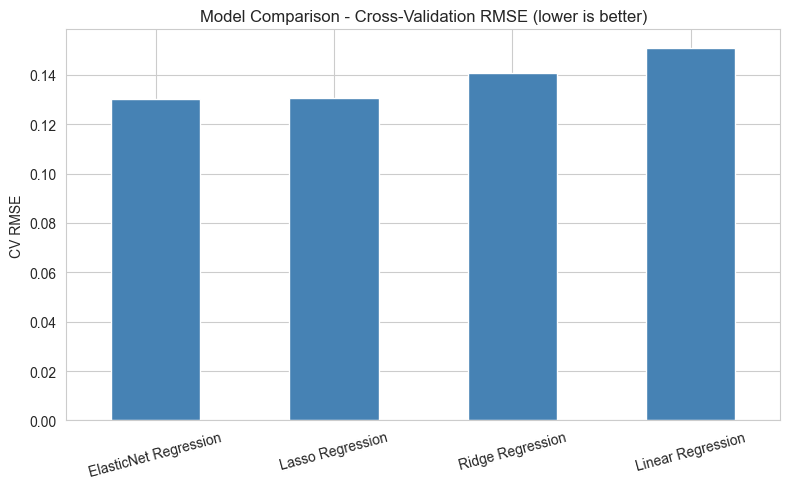

In [19]:
plt.figure(figsize=(8, 5))
results_df['CV RMSE'].plot(kind='bar', color='steelblue')
plt.title("Model Comparison - Cross-Validation RMSE (lower is better)")
plt.ylabel("CV RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [20]:
# Automatically selection of best model 

best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(results_df.loc[best_model_name])


Best Model: ElasticNet Regression
RMSE of Train        0.110044
RMSE of Test         0.142704
MAE of Train         0.074643
MAE of Test          0.091311
R2 Score of Train    0.920562
R2 Score of Test     0.890872
CV RMSE              0.130330
Name: ElasticNet Regression, dtype: float64


In [21]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scale, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")
joblib.dump(X.median().to_dict(), "default_values.pkl")
joblib.dump(list(high_skew), "skewed_features.pkl")

['skewed_features.pkl']

In [22]:
print(X.columns)

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=279)


In [23]:
print('GrLivArea' in high_skew)
print('TotalBsmtSF' in high_skew)

True
True
